Using 578 stars with Mstar ≤ 2.0 M☉
Loaded parameters:
μ (mean c): -5.623
σ (std c): 0.541
Age exponent (a): -0.411
Mass exponent (b): 1.137
Data points: 578

BOOTSTRAP UNCERTAINTY ANALYSIS FOR a, b, AND c PARAMETERS
Running bootstrap analysis...
Bootstrap results from 500 successful fits:
Age exponent (a): -0.413 ± 0.049
Mass exponent (b): 1.135 ± 0.106
Amplitude (c): -5.612 ± 0.319

INDIVIDUAL PARAMETER SIMULATION FOR a, b, AND c
Simulated 578 a-values
Simulated a mean: -0.413 (bootstrap: -0.413)
Simulated a std: 0.047 (bootstrap: 0.049)
Simulated 578 b-values
Simulated b mean: 1.136 (bootstrap: 1.135)
Simulated b std: 0.113 (bootstrap: 0.106)
Simulated 578 c-values
Simulated c mean: -5.610 (true: -5.623)
Simulated c std: 0.547 (true: 0.541)


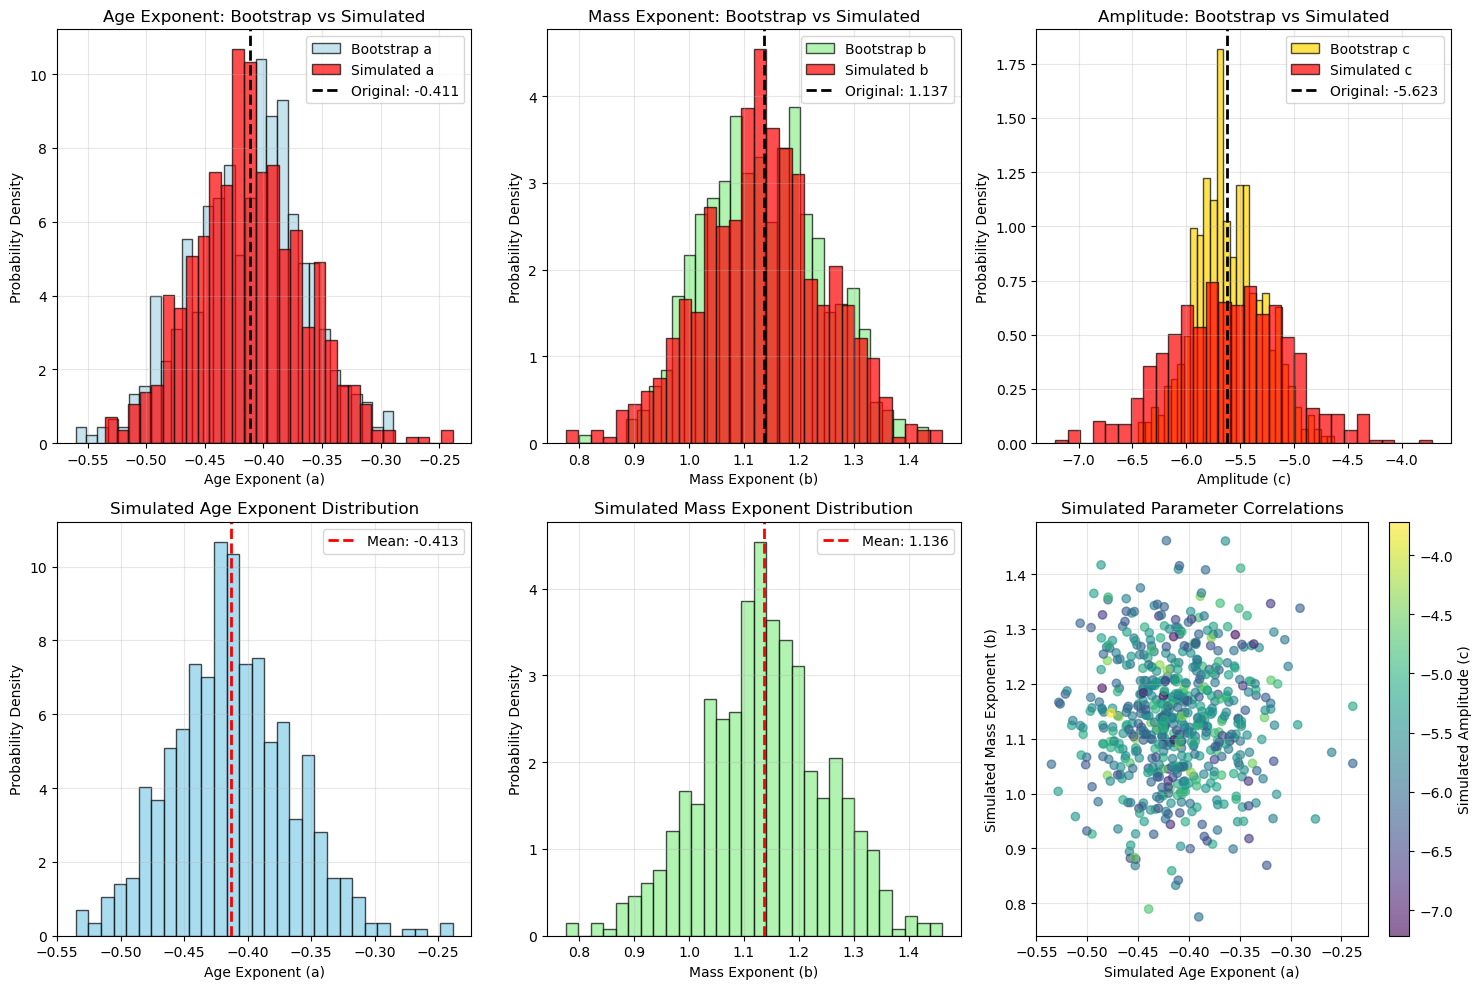


COMBINED UNCERTAINTY ANALYSIS REPORT

FINAL MODEL WITH UNCERTAINTIES:
logMacc = a×logAge + b×logMstar + c
where:
  a ~ N(μ=-0.413, σ=0.049)
  b ~ N(μ=1.135, σ=0.106)
  c ~ N(μ=-5.623, σ=0.541)

PARAMETER STABILITY ASSESSMENT:
Age exponent uncertainty: ±0.049 (11.9% of mean)
Mass exponent uncertainty: ±0.106 (9.4% of mean)
Amplitude uncertainty: ±0.541 (9.6% of mean)

MODEL ROBUSTNESS:
Age exponent consistency (KS p-value): 0.060 ✓ Consistent
Mass exponent consistency (KS p-value): 0.408 ✓ Consistent
Amplitude consistency (KS p-value): 0.000 ✗ Different

PRACTICAL IMPLICATIONS:
1. Age dependence: logMacc changes by -0.413 ± 0.049 per logAge unit
2. Mass dependence: logMacc changes by 1.135 ± 0.106 per logMstar unit
3. Intrinsic scatter: Individual stars vary by ±0.541 around the mean relationship
4. Total prediction uncertainty combines all three sources
PDF report skipped
✓ Parameter simulation results saved to 'parameter_simulation_results.npy'


In [1]:
"""
Parameter Uncertainty Distributions - Bootstrap and Monte Carlo Parameter Estimation
Updated: Jun 29 2026

Input Files:
power_law_model.npy (from main analysis)
stellar_accretion_data.csv (from main analysis)

Output Files:
parameter_simulation_results.npy
Parameter_Uncertainty_Distributions_Report.pdf (Section 5) - only if user prompts

1 - parameter_simulation_results.npy:
    Contains bootstrap-sampled distributions for age exponent (a), mass exponent (b), and amplitude (c),
    simulated parameters from the combined method, and summary statistics.
    Stores all uncertainty results for reuse without rerunning the bootstrap analysis.

2 - Parameter_Uncertainty_Distributions_Report.pdf:
    A comprehensive PDF report containing parameter distribution plots, statistical validation results, 
    and uncertainty interpretation. For ease of reading and distribution.

This differs from abc_values_uncertainty_analysis.ipynb in that it performs a bootstrap analysis for all three parameters (a, b, c) 
instead of using the residual method for c.

This has 5 sections:
1 - Bootstrap uncertainty analysis for a, b, and c parameters
2 - Individual parameter simulation using bootstrap distributions
3 - Visualize parameter distributions and correlations
4 - Combined uncertainty analysis report and statistical validation
5 - PDF report generation with visualizations and summary
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.special import erfinv
from scipy.stats import ks_2samp, norm
from matplotlib.backends.backend_pdf import PdfPages
import os

# Set random seed for reproducibility
np.random.seed(42)

# Load pre-computed data
df = pd.read_csv('stellar_accretion_data.csv')

# FILTER FOR STARS <=2 SOLAR MASSES
df = df[df['Mstar'] <= 2.0]
print(f"Using {len(df)} stars with Mstar ≤ 2.0 M☉")

# Load all parameters from single file
model_params = np.load('power_law_model.npy', allow_pickle=True).item()
log_amp = model_params['log_amp']
age_exp = model_params['age_exp']
mass_exp = model_params['mass_exp']
mu = model_params['mu']
sigma = model_params['sigma']

print("Loaded parameters:")
print(f"μ (mean c): {mu:.3f}")
print(f"σ (std c): {sigma:.3f}")
print(f"Age exponent (a): {age_exp:.3f}")
print(f"Mass exponent (b): {mass_exp:.3f}")
print(f"Data points: {len(df)}")

# Vectorized Gaussian distribution function
def gaussian_dist(mu, sigma, n_points):
    """Generate n_points random values from a Gaussian distribution."""
    return mu + sigma * np.sqrt(2) * erfinv(2 * np.random.random(n_points) - 1)

# Triple power law model function
def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar

# ============================================================================
# Section 1: BOOTSTRAP ANALYSIS FOR a, b, AND c PARAMETERS
# ============================================================================
print("\n" + "="*60)
print("BOOTSTRAP UNCERTAINTY ANALYSIS FOR a, b, AND c PARAMETERS")
print("="*60)

def bootstrap_triple_power_law(df, n_bootstraps=500):
    """Perform bootstrap resampling to estimate parameter uncertainties."""
    a_values = []
    b_values = []
    c_values = []
    failed_fits = 0
    
    model = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])
    
    for i in range(n_bootstraps):
        bootstrap_sample = df.sample(n=len(df), replace=True)
        
        log_age_data = bootstrap_sample['logAge'].values
        log_mstar_data = bootstrap_sample['logMstar'].values
        log_macc_data = bootstrap_sample['logMacc'].values
        
        params = model.make_params()
        params.add('log_amplitude', value=-7, min=-12, max=5)
        params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
        params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)
        
        try:
            result = model.fit(log_macc_data, params, 
                             log_age=log_age_data, log_mstar=log_mstar_data)
            a_values.append(result.params['age_exponent'].value)
            b_values.append(result.params['mass_exponent'].value)
            c_values.append(result.params['log_amplitude'].value)
        except Exception:
            failed_fits += 1
            continue
    
    if failed_fits > 0:
        print(f"Warning: {failed_fits} bootstrap fits failed ({failed_fits/n_bootstraps*100:.1f}%)")
    
    return np.array(a_values), np.array(b_values), np.array(c_values)

# Run bootstrap analysis
print("Running bootstrap analysis...")
a_boot, b_boot, c_boot = bootstrap_triple_power_law(df, n_bootstraps=500)

print(f"Bootstrap results from {len(a_boot)} successful fits:")
print(f"Age exponent (a): {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f}")
print(f"Mass exponent (b): {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f}")
print(f"Amplitude (c): {np.mean(c_boot):.3f} ± {np.std(c_boot):.3f}")

# ============================================================================
# Section 2: INDIVIDUAL PARAMETER SIMULATION
# ============================================================================
print("\n" + "="*60)
print("INDIVIDUAL PARAMETER SIMULATION FOR a, b, AND c")
print("="*60)

n_simulations = len(df)

# Simulate a values (age exponent)
simulated_a = gaussian_dist(np.mean(a_boot), np.std(a_boot), n_simulations)
print(f"Simulated {n_simulations} a-values")
print(f"Simulated a mean: {simulated_a.mean():.3f} (bootstrap: {np.mean(a_boot):.3f})")
print(f"Simulated a std: {simulated_a.std():.3f} (bootstrap: {np.std(a_boot):.3f})")

# Simulate b values (mass exponent)  
simulated_b = gaussian_dist(np.mean(b_boot), np.std(b_boot), n_simulations)
print(f"Simulated {n_simulations} b-values")
print(f"Simulated b mean: {simulated_b.mean():.3f} (bootstrap: {np.mean(b_boot):.3f})")
print(f"Simulated b std: {simulated_b.std():.3f} (bootstrap: {np.std(b_boot):.3f})")

# Simulate c values (amplitude)
simulated_c = gaussian_dist(mu, sigma, n_simulations)
print(f"Simulated {n_simulations} c-values")
print(f"Simulated c mean: {simulated_c.mean():.3f} (true: {mu:.3f})")
print(f"Simulated c std: {simulated_c.std():.3f} (true: {sigma:.3f})")

# ============================================================================
# Section 3: VISUALIZE PARAMETER DISTRIBUTIONS
# ============================================================================
fig_params, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: a-value comparison (bootstrap vs simulated)
axes[0,0].hist(a_boot, bins=30, alpha=0.7, density=True, color='lightblue', 
               label='Bootstrap a', edgecolor='black')
axes[0,0].hist(simulated_a, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated a', edgecolor='black')
axes[0,0].axvline(age_exp, color='black', linestyle='--', linewidth=2, 
                  label=f'Original: {age_exp:.3f}')
axes[0,0].set_xlabel('Age Exponent (a)')
axes[0,0].set_ylabel('Probability Density')
axes[0,0].set_title('Age Exponent: Bootstrap vs Simulated')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: b-value comparison (bootstrap vs simulated)
axes[0,1].hist(b_boot, bins=30, alpha=0.7, density=True, color='lightgreen', 
               label='Bootstrap b', edgecolor='black')
axes[0,1].hist(simulated_b, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated b', edgecolor='black')
axes[0,1].axvline(mass_exp, color='black', linestyle='--', linewidth=2, 
                  label=f'Original: {mass_exp:.3f}')
axes[0,1].set_xlabel('Mass Exponent (b)')
axes[0,1].set_ylabel('Probability Density')
axes[0,1].set_title('Mass Exponent: Bootstrap vs Simulated')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: c-value comparison (bootstrap vs simulated)
axes[0,2].hist(c_boot, bins=30, alpha=0.7, density=True, color='gold', 
               label='Bootstrap c', edgecolor='black')
axes[0,2].hist(simulated_c, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated c', edgecolor='black')
axes[0,2].axvline(log_amp, color='black', linestyle='--', linewidth=2, 
                  label=f'Original: {log_amp:.3f}')
axes[0,2].set_xlabel('Amplitude (c)')
axes[0,2].set_ylabel('Probability Density')
axes[0,2].set_title('Amplitude: Bootstrap vs Simulated')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Simulated age exponent distribution
axes[1,0].hist(simulated_a, bins=30, alpha=0.7, density=True, color='skyblue', edgecolor='black')
axes[1,0].axvline(np.mean(simulated_a), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(simulated_a):.3f}')
axes[1,0].set_xlabel('Age Exponent (a)')
axes[1,0].set_ylabel('Probability Density')
axes[1,0].set_title('Simulated Age Exponent Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Simulated mass exponent distribution
axes[1,1].hist(simulated_b, bins=30, alpha=0.7, density=True, color='lightgreen', edgecolor='black')
axes[1,1].axvline(np.mean(simulated_b), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(simulated_b):.3f}')
axes[1,1].set_xlabel('Mass Exponent (b)')
axes[1,1].set_ylabel('Probability Density')
axes[1,1].set_title('Simulated Mass Exponent Distribution')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Parameter correlations
scatter = axes[1,2].scatter(simulated_a, simulated_b, c=simulated_c, alpha=0.6, cmap='viridis')
axes[1,2].set_xlabel('Simulated Age Exponent (a)')
axes[1,2].set_ylabel('Simulated Mass Exponent (b)')
axes[1,2].set_title('Simulated Parameter Correlations')
plt.colorbar(scatter, ax=axes[1,2], label='Simulated Amplitude (c)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Section 4: COMBINED UNCERTAINTY ANALYSIS REPORT
# ============================================================================
print("\n" + "="*60)
print("COMBINED UNCERTAINTY ANALYSIS REPORT")
print("="*60)

print(f"\nFINAL MODEL WITH UNCERTAINTIES:")
print(f"logMacc = a×logAge + b×logMstar + c")
print(f"where:")
print(f"  a ~ N(μ={np.mean(a_boot):.3f}, σ={np.std(a_boot):.3f})")
print(f"  b ~ N(μ={np.mean(b_boot):.3f}, σ={np.std(b_boot):.3f})") 
print(f"  c ~ N(μ={mu:.3f}, σ={sigma:.3f})")

print(f"\nPARAMETER STABILITY ASSESSMENT:")
print(f"Age exponent uncertainty: ±{np.std(a_boot):.3f} ({np.std(a_boot)/np.abs(np.mean(a_boot))*100:.1f}% of mean)")
print(f"Mass exponent uncertainty: ±{np.std(b_boot):.3f} ({np.std(b_boot)/np.abs(np.mean(b_boot))*100:.1f}% of mean)")
print(f"Amplitude uncertainty: ±{sigma:.3f} ({sigma/np.abs(mu)*100:.1f}% of mean)")

print(f"\nMODEL ROBUSTNESS:")
# KS tests for parameter consistency
ks_a, p_a = ks_2samp(a_boot, simulated_a)
ks_b, p_b = ks_2samp(b_boot, simulated_b)
ks_c, p_c = ks_2samp(c_boot, simulated_c)

print(f"Age exponent consistency (KS p-value): {p_a:.3f} {'✓ Consistent' if p_a > 0.05 else '✗ Different'}")
print(f"Mass exponent consistency (KS p-value): {p_b:.3f} {'✓ Consistent' if p_b > 0.05 else '✗ Different'}")
print(f"Amplitude consistency (KS p-value): {p_c:.3f} {'✓ Consistent' if p_c > 0.05 else '✗ Different'}")

print(f"\nPRACTICAL IMPLICATIONS:")
print(f"1. Age dependence: logMacc changes by {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f} per logAge unit")
print(f"2. Mass dependence: logMacc changes by {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f} per logMstar unit")
print(f"3. Intrinsic scatter: Individual stars vary by ±{sigma:.3f} around the mean relationship")
print(f"4. Total prediction uncertainty combines all three sources")

# ============================================================================
# Section 5: CREATE COMBINED PDF REPORT
# ============================================================================
PDF_FILENAME = 'Parameter_Uncertainty_Distributions_Report.pdf'

def ask_save_pdf():
    response = input("\nSave PDF report? (y/n): ").strip().lower()
    return response in ['y', 'yes', '1']

def create_combined_report():
    try:
        with PdfPages(PDF_FILENAME) as pdf:
            pdf.savefig(fig_params, bbox_inches='tight')
            
            fig_text, ax_text = plt.subplots(figsize=(8.5, 11))
            ax_text.axis('off')
            
            report_text = []
            report_text.append("COMBINED UNCERTAINTY ANALYSIS REPORT")
            report_text.append("Triple Power Law Parameter Uncertainties")
            report_text.append("=" * 50)
            report_text.append("")
            report_text.append("MODEL: logMacc = a×logAge + b×logMstar + c")
            report_text.append("")
            report_text.append("PARAMETER DISTRIBUTIONS:")
            report_text.append(f"Age exponent (a) ~ N(μ={np.mean(a_boot):.3f}, σ={np.std(a_boot):.3f})")
            report_text.append(f"Mass exponent (b) ~ N(μ={np.mean(b_boot):.3f}, σ={np.std(b_boot):.3f})")
            report_text.append(f"Amplitude (c) ~ N(μ={mu:.3f}, σ={sigma:.3f})")
            report_text.append("")
            report_text.append("UNCERTAINTY QUANTIFICATION:")
            report_text.append(f"Age exponent: ±{np.std(a_boot):.3f} ({np.std(a_boot)/np.abs(np.mean(a_boot))*100:.1f}% relative)")
            report_text.append(f"Mass exponent: ±{np.std(b_boot):.3f} ({np.std(b_boot)/np.abs(np.mean(b_boot))*100:.1f}% relative)")
            report_text.append(f"Amplitude: ±{sigma:.3f} ({sigma/np.abs(mu)*100:.1f}% relative)")
            report_text.append("")
            report_text.append("MODEL INTERPRETATION:")
            report_text.append(f"• Accretion rate decreases by {np.abs(np.mean(a_boot)):.3f} in logMacc per logAge")
            report_text.append(f"• Higher mass stars accrete {np.exp(np.mean(b_boot)):.2f}x more per mass decade")
            report_text.append(f"• Individual stars show {sigma:.3f} dex intrinsic scatter")
            report_text.append("")
            report_text.append("STATISTICAL VALIDATION:")
            report_text.append(f"Bootstrap iterations: {len(a_boot)}")
            report_text.append(f"Parameter consistency (KS tests):")
            report_text.append(f"  Age exponent: p = {p_a:.3f}")
            report_text.append(f"  Mass exponent: p = {p_b:.3f}")
            report_text.append(f"  Amplitude: p = {p_c:.3f}")
            
            ax_text.text(0.05, 0.95, '\n'.join(report_text), transform=ax_text.transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            pdf.savefig(fig_text, bbox_inches='tight')
            plt.close(fig_text)
            
            # Add metadata
            d = pdf.infodict()
            d['Title'] = 'Parameter Uncertainty Distributions Analysis'
            d['Author'] = 'Capstone Research Project'
            d['Subject'] = 'Triple Power Law Parameter Uncertainty Analysis'

        print(f"✓ Combined report saved as: {PDF_FILENAME}")
    except Exception as e:
        print(f"Error saving PDF: {e}")

if ask_save_pdf():
    create_combined_report()
else:
    print("PDF report skipped")

# Close the figure to free memory
plt.close(fig_params)

# Save all simulation results
np.save('parameter_simulation_results.npy', {
    'simulated_a': simulated_a,
    'simulated_b': simulated_b, 
    'simulated_c': simulated_c,
    'bootstrap_a': a_boot,
    'bootstrap_b': b_boot,
    'bootstrap_c': c_boot,
    'summary_stats': {
        'a_mean': np.mean(a_boot), 'a_std': np.std(a_boot),
        'b_mean': np.mean(b_boot), 'b_std': np.std(b_boot), 
        'c_mean': mu, 'c_std': sigma
    }
})
print("✓ Parameter simulation results saved to 'parameter_simulation_results.npy'")